In [1]:
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
import cv2 as cv

from torch import nn
from torch.utils.data import DataLoader
from torchvision.models import (
    resnet18,
    ResNet18_Weights,
    resnet34,
    ResNet34_Weights,
    resnet50,
    ResNet50_Weights,
    resnet101,
    ResNet101_Weights,
    resnet152,
    ResNet152_Weights,
    densenet121,
    DenseNet121_Weights,
    densenet161,
    DenseNet161_Weights,
    densenet169,
    DenseNet169_Weights,
    densenet201,
    DenseNet201_Weights,
    mobilenet_v2,
    MobileNet_V2_Weights,
    mobilenet_v3_small,
    MobileNet_V3_Small_Weights,
    mobilenet_v3_large,
    MobileNet_V3_Large_Weights,
)
from torchvision.transforms import v2
import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint, Timer
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from lightning.pytorch.loggers import TensorBoardLogger
from torchinfo import summary
import segmentation_models_pytorch as smp
from utils import (
    OCTDataset, 
    IterableOCTDataset, 
    plotimg, 
    LitSupervised, 
    OCTRandAugment, 
    TransferLearningModel,
    TransferLearning,
    GLOBAL_CONFIG,
    product_dict, 
    LOGDIR, 
    OCTCollate,
)
from core_utils import stringify_map, get_normal_statistics, cvreadimg

/home/polyester/Desktop/Programming/OCT-Project/.venv/lib/python3.13/site-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)


In [2]:
dataset = OCTDataset.from_path("OCTDataMendeley_resized")

In [3]:
train_paths, test_paths, train_labels, test_labels = train_test_split(
    dataset.paths, 
    dataset.targets,
    stratify=dataset.targets, 
    test_size=1000, 
    random_state=42
)
train_paths, val_paths = train_test_split(
    train_paths, 
    stratify=train_labels, 
    test_size=0.2, 
    random_state=42
)

In [4]:
train_dataset = OCTDataset(train_paths)
val_dataset = OCTDataset(val_paths)
test_dataset = OCTDataset(test_paths)
del dataset
len(train_dataset), len(val_dataset), len(test_dataset)

(86647, 21662, 1000)

In [5]:
#get_normal_statistics(IterableOCTDataset(train_dataset))
#(tensor([48.6167, 48.6167, 48.6167]), tensor([56.4110, 56.4110, 56.4110]))

In [6]:
OCTDataset.classes()

['DME', 'AMD', 'DRUSEN', 'DR', 'CNV', 'NORMAL', 'CSR', 'MH']

In [7]:
train_dataset.class_dist(), val_dataset.class_dist() 

({'NORMAL': 40736, 'CNV': 29689, 'DME': 9194, 'DRUSEN': 7028},
 {'CNV': 7423, 'NORMAL': 10184, 'DME': 2298, 'DRUSEN': 1757})

In [8]:
train_dataset.paths[400], train_dataset.targets[400]

(PosixPath('OCTDataMendeley_resized/train/NORMAL/NORMAL-4001769-2.jpeg'), 5)

In [9]:
from collections import Counter
from pprint import pprint

counts = dict(Counter(train_dataset.paths))
with open("../test/counts.txt", "w") as f:
    pprint(counts, stream=f)

In [10]:
40736/10184, 29689/7423, 9194/2298, 7028/1757 

(4.0, 3.9995958507342046, 4.000870322019147, 4.0)

In [11]:
train_dataset.oversample()

In [12]:
train_dataset.class_dist(), val_dataset.class_dist() 

({'NORMAL': 40736, 'CNV': 40736, 'DME': 40736, 'DRUSEN': 40736},
 {'CNV': 7423, 'NORMAL': 10184, 'DME': 2298, 'DRUSEN': 1757})

In [13]:
_index = 6
path, instance, label = test_dataset[_index]

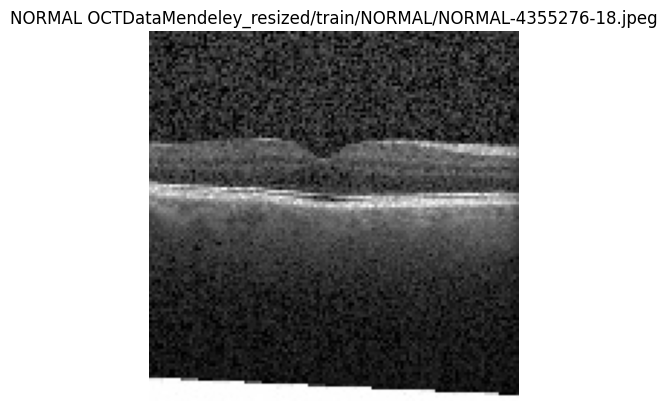

In [14]:
plotimg(instance, f"{OCTDataset.classes()[label]} {path}")

In [15]:
train_loader = DataLoader(
    train_dataset, 
    batch_size=GLOBAL_CONFIG["batch_size"], 
    shuffle=True,
    num_workers=7,
    collate_fn=OCTCollate()
)
validation_loader = DataLoader(
    val_dataset, 
    batch_size=GLOBAL_CONFIG["batch_size"], 
    num_workers=7,
    collate_fn=OCTCollate()
)

In [16]:
# for batch in validation_loader:
#     path, inp, target = batch
#     print(path, inp.shape, target.shape)

In [17]:
TransferLearning.models = {
    "mobilenet_v2": TransferLearningModel(mobilenet_v2, MobileNet_V2_Weights.IMAGENET1K_V2),
    "mobilenet_v3_small": TransferLearningModel(mobilenet_v3_small, MobileNet_V3_Small_Weights.IMAGENET1K_V1),
    "mobilenet_v3_large": TransferLearningModel(mobilenet_v3_large, MobileNet_V3_Large_Weights.IMAGENET1K_V2),
    "resnet18": TransferLearningModel(resnet18, ResNet18_Weights.IMAGENET1K_V1),
    "resnet34": TransferLearningModel(resnet34, ResNet34_Weights.IMAGENET1K_V1),
    "resnet50": TransferLearningModel(resnet50, ResNet50_Weights.IMAGENET1K_V1),
    "resnet101": TransferLearningModel(resnet101, ResNet101_Weights.IMAGENET1K_V2),
    #"resnet152": TransferLearningModel(resnet152, ResNet152_Weights.IMAGENET1K_V1),
    #"densenet121": TransferLearningModel(densenet121, DenseNet121_Weights.IMAGENET1K_V1),
    #"densenet161": TransferLearningModel(densenet161, DenseNet161_Weights.IMAGENET1K_V1),
    #"densenet169": TransferLearningModel(densenet169, DenseNet169_Weights.IMAGENET1K_V1),
    #"densenet201": TransferLearningModel(densenet201, DenseNet201_Weights.IMAGENET1K_V1),
}

In [18]:
def train_model(config, ckpt_config = None):
   current_name = stringify_map(config, ", ")
   version_name = stringify_map(config)
   logdir = config["logdir"]
   print(current_name)
   logger = TensorBoardLogger(
      save_dir=".",
      name=logdir,
      version=version_name,
   )
   litmodel = LitSupervised(config, OCTDataset.classes())
   metric_names = litmodel.metric_names()
   timer = Timer()
   trainer = L.Trainer(
      logger=logger,
      accelerator="gpu",
      callbacks=[
         timer,
         EarlyStopping(
            monitor=f"{LitSupervised.SET_NAME_VAL}_loss", 
            mode="min",
            min_delta=1e-3, 
            patience=8,
         ),
      ] + [
         ModelCheckpoint(
            dirpath=None,  # Uses logger's default directory
            monitor=metric_name,  # Metric to monitor
            filename="top-"+metric_name+"-epoch:{epoch:d}-step:{step:d}-{"+metric_name+"}",
            save_top_k=1,  # Save top 1 checkpoints
            mode="max",  # Save highest
            save_last=i==0,  # Also save the last checkpoint
         ) for i, metric_name in enumerate(metric_names)
      ],
   )
   ckpt_path = None
   if isinstance(ckpt_config, dict):
      ckpt_version_name = stringify_map(ckpt_config)
      ckpts_path = Path(logdir, ckpt_version_name, "checkpoints")
      ckpt_path = sorted(list(ckpts_path.iterdir()))[-1]
   trainer.fit(
      model=litmodel, 
      train_dataloaders=train_loader, val_dataloaders=validation_loader,
      ckpt_path=ckpt_path,
   )
   train_time = timer.time_elapsed("train")
   val_time = timer.time_elapsed("validate")
   total_fit_time = train_time + val_time
   print(f"Training completed in {train_time} secs")
   print(f"Validation completed in {train_time} secs")
   print(f"Total time is {total_fit_time} secs")

In [19]:
def predict_samplewise(config, dataloader: DataLoader):
    current_name = stringify_map(config, ", ")
    version_name = stringify_map(config)
    logdir = config["logdir"]
    print(current_name)
    logger = TensorBoardLogger(
       save_dir=".",
       name=logdir,
       version=version_name,
    )
    ckpt_path = Path(logdir, version_name, "checkpoints", "last.ckpt")
    litmodel = LitSupervised.load_from_checkpoint(
        checkpoint_path=ckpt_path,
        config=config,
        classes=OCTDataset.classes(),
    )
    trainer = L.Trainer(
      logger=logger,
      accelerator="gpu"
    )
    predictions = trainer.predict(
        model=litmodel, 
        dataloaders=dataloader,
    )
    return predictions

In [20]:
#_ = predict_samplewise(
#    {
#           "run": "step2", 
#           "logdir": "logs_oversampled",
#           "model": "resnet34", 
#           "magnitude": 0, 
#           "lr": 1e-4
#    },
#    validation_loader,
#)

In [21]:
# for p in sorted(Path("logs_oversampled").rglob("*.csv")):
#     print(p)

In [ ]:
def plot_nontp(logdir, numsamples=2):
    numclasses = len(OCTDataset.classes())
    rows = (numclasses*numsamples*3)//2
    cols = 2
    min_size_per_ax = 5
    fig, ax = plt.subplots(
        rows, 
        cols,
        figsize=(cols * min_size_per_ax, rows * min_size_per_ax)
    )
    plt.subplots_adjust(wspace=0.4, hspace=0.4)

    logdir = Path(logdir)
    i=0

    for csv in sorted(logdir.rglob("*.csv")):
        statype = csv.stem.split("_")[-1].lower()
        if statype == "tn":
            continue
        _pd = pd.read_csv(csv)
        if len(_pd) > numsamples:
            pdsampled = _pd.sample(n=numsamples)
            for j, row in pdsampled.iterrows():
                path = Path(row["path"])
                original_path = Path(path.parts[0].split("_")[0], *path.parts[1:])

                pred = row["prediction"] if "prediction" in row else ""
                img_bgr_original = cvreadimg(original_path)
                img_rgb_original = cv.cvtColor(img_bgr_original, cv.COLOR_BGR2RGB)

                img_bgr = cvreadimg(path)
                img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

                ax[i][0].imshow(img_rgb_original)
                ax[i][0].set_title(f"{statype.upper()} {original_path} {pred}")
                ax[i][1].imshow(img_rgb)
                ax[i][1].set_title(f"{statype.upper()} {path} {pred}")
                i+=1

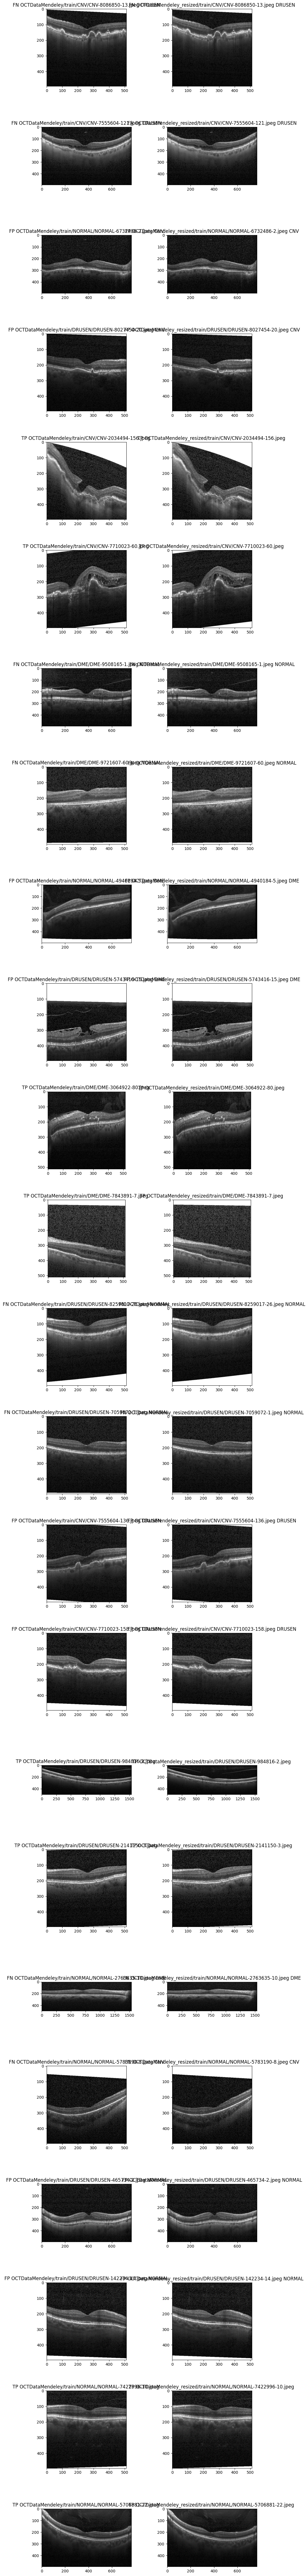

In [29]:
plot_nontp("logs_oversampled")

In [ ]:
for model_name in TransferLearning.models:
    print(f"Running {model_name}:")
    train_model(
        {
            "run": "step1", 
            "logdir": "logs_oversampled",
            "model": model_name, 
            "magnitude": 0, 
            "lr": 1e-3
        },
    )
    train_model(
        {
            "run": "step2", 
            "logdir": "logs_oversampled",
            "model": model_name, 
            "magnitude": 0, 
            "lr": 1e-4
        },
        {
            "run": "step1", 
            "logdir": "logs_oversampled",
            "model": model_name, 
            "magnitude": 0, 
            "lr": 1e-3
        }
    )